In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\glory\Cleaned_E-Commerce_data.csv")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010.0,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010.0,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,December
...,...,...,...,...,...,...,...,...,...,...,...
166358,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011.0,December
166359,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011.0,December
166360,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011.0,December
166361,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011.0,December


In [4]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'],errors='coerce')

In [5]:
df['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
166358   2011-12-09 12:50:00
166359   2011-12-09 12:50:00
166360   2011-12-09 12:50:00
166361   2011-12-09 12:50:00
166362   2011-12-09 12:50:00
Name: InvoiceDate, Length: 166363, dtype: datetime64[ns]

In [6]:
df['StockCode']=df['StockCode'].str.strip()

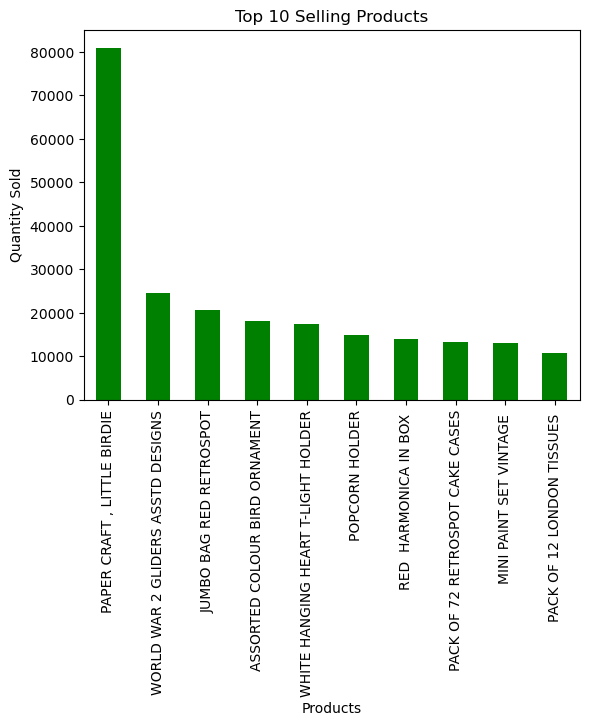

In [24]:
#Top Selling products
Top_Products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

#Visualization using Matplotlib
Top_Products.plot(kind='bar',color='green')
plt.title("Top 10 Selling Products")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")
plt.show()
#Insight
#The top 10 products are contributing high sales, indicating a strong demand.

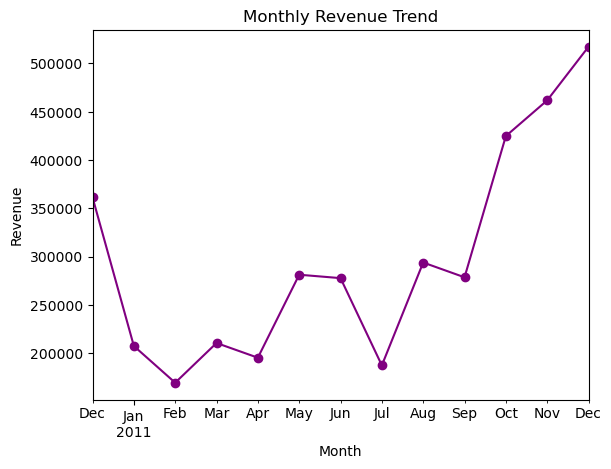

In [25]:
#Monthly Revenue Trend
df['Month']=df['InvoiceDate'].dt.to_period('M')

Monthly_sales = df.groupby('Month')['TotalPrice'].sum()

Monthly_sales.plot(kind='line',color='purple',marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()
#Insight
#Revenue shows a strong upward trend towards the end of the year,with peak sales in November and December, indicating seasonal demand likely driven by holiday shopping.

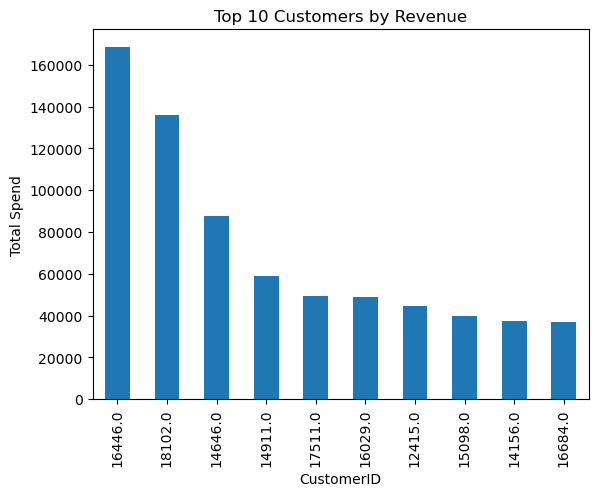

In [14]:
#Top Customers
Top_Customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Top_Customers.plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("CustomerID")
plt.ylabel("Total Spend")
plt.show()
#Insight
#A small group of customers contributes to total revenue, highligjting the importance of high-value customers and the need for retention strategies.

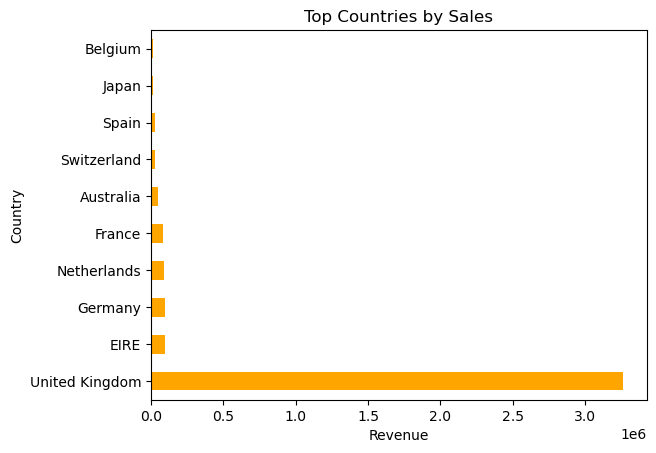

In [26]:
#Country Wise Sales
Country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Country_sales.plot(kind='barh',color='orange')
plt.title("Top Countries by Sales")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()
#Insight
#Sales are concentrated in a few key countries,suggesting strong regional markets and oppurtunities for targeted expansion.

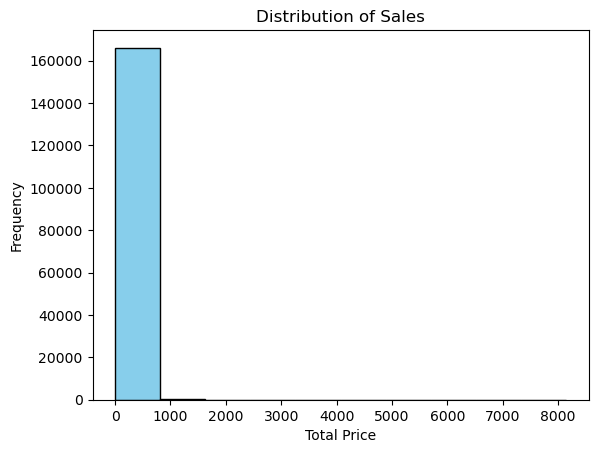

In [31]:
#Sales Distribution
df[df['TotalPrice'] < 10000]['TotalPrice'].plot(kind='hist',color='skyblue',edgecolor='black')
plt.title("Distribution of Sales")
plt.xlabel("Total Price")
plt.show()
#Insight 
#Most transactions are low-value purchases, while a few high-value transactions act as outliters, indicating bulk or wholesale buying behavior.

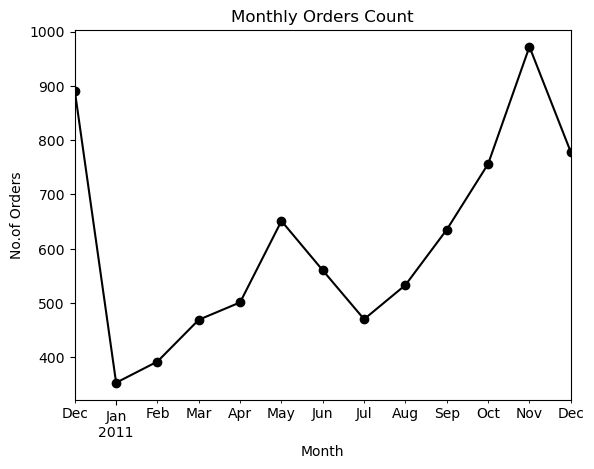

In [30]:
#Montly Orders Count
df['Month']=df['InvoiceDate'].dt.to_period('M')
orders=df.groupby('Month')['InvoiceNo'].nunique()

orders.plot(kind='line',color='black',marker='o')
plt.title("Monthly Orders Count")
plt.xlabel("Month")
plt.ylabel("No.of Orders")
plt.show()
#Insight
#Order volume follows a similar trend to revenue, confirming that higher sales months are driven by increased customer activity.